In [1]:
#pip install tqdm matplotlib numpy torch scikit-learn joblib

In [2]:
import warnings
import chip_temp_pred_models as ctpm
import utilities
import interconnect_calculator as inter_cal
import temperature_calculator as temp_cal

import time
import torch
import sys
import os
import random
import math


from tqdm import tqdm
warnings.filterwarnings("ignore")


In [3]:
# At the beginning of the file
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Notebook using device: {DEVICE}")

Notebook using device: cuda


In [4]:
# overlap constraints

def is_2_chip_overlapping_cuda(chip1, chip2, min_edge_dist:float=0.2): 
    """
    Check if two chiplets are overlapping.
    input: 
        chip1: the first chiplet
        chip2: the second chiplet
        min_edge_dist: the minimum edge distance between two chiplets
    output: 
        True: if two chiplets are overlapping
        False: if two chiplets are not overlapping
    """
    # x1, y1 = chip1[0], chip1[1]
    # w1, h1 = chip1[2], chip1[3]
    # x2, y2 = chip2[0], chip2[1]
    # w2, h2 = chip2[2], chip2[3]

    x1, y1, w1, h1 = \
        chip1[0].item(), chip1[1].item(), chip1[2].item(), chip1[3].item()
    try: 
        x2, y2, w2, h2 = \
            chip2[0].item(), chip2[1].item(), chip2[2].item(), chip2[3].item()
    except: 
        print(chip2)

    no_overlap = \
        (x1 + w1 + min_edge_dist <= x2 or \
            x2 + w2 + min_edge_dist <= x1) or \
        (y1 + h1 + min_edge_dist <= y2 or \
            y2 + h2 + min_edge_dist <= y1)
      
    
    return not no_overlap

def check_overlap_within_layout_cuda(layout, min_edge_dist: float = 0.2):
    """
    Check if there are overlapping chiplets within the layout.
    input: 
        layout: the layout of the chiplets
        chiplets: the chiplets
    output: 
        True: if there are overlapping chiplets
        False: if there are no overlapping chiplets
    """

    # Convert to tensor if not already
    if not torch.is_tensor(layout):
        layout = torch.tensor(layout, device=DEVICE)
    
    n = len(layout)
    # Create tensors for all pairs of chiplets
    i_indices, j_indices = torch.triu_indices(n, n, offset=1)
    
    # Vectorized overlap checking
    overlaps = torch.stack([
        torch.tensor(is_2_chip_overlapping_cuda(layout[i], layout[j], min_edge_dist=min_edge_dist))
        for i, j in zip(i_indices, j_indices)
    ])
    
    return overlaps.any()

def is_1_chip_overlapping_with_layout(curr_chip, layout): 
    overlaps = torch.stack([
        is_2_chip_overlapping_cuda(curr_chip, chip)
        for chip in layout
    ])

    return overlaps.any()

def is_overlapping_in_init_grid_cuda(x_c, y_c, len_c, wid_c, index_c, layout, min_edge_dist): 
    """
    Check if a chiplet is overlapping with other chiplets in the layout.
    """

    curr_chip = torch.tensor([x_c, y_c, len_c, wid_c, index_c], device=DEVICE)
    n = len(layout)
    i_indices = range(n)
    
    overlaps = torch.stack([
        torch.tensor(is_2_chip_overlapping_cuda(curr_chip, layout[i], min_edge_dist=min_edge_dist), device=DEVICE)
        for i in i_indices
    ])

    return overlaps.any()





In [5]:
# general helper function
def get_shape_of_board_cuda(layout, chiplets, margin_width=1.0): 
    """
    Get the shape of the board.
    input: 
        layout: the layout of the chiplets
        chiplets: the chiplets
        margin_width: the margin width of the board
    output: 
        the shape of the board: length and width of the board
    """
    x_max, x_min, y_max, y_min = float('-inf'), float('inf'),float('-inf'),float('inf')

    for chip in layout: 
        # chiplet_index = int(chip[-1].item())
        x_max = max(x_max, chip[0].item() + chip[2].item())
        x_min = min(x_min, chip[0].item())
        y_max = max(y_max, chip[1].item() + chip[3].item())
        y_min = min(y_min, chip[1].item())

    board_len = abs(x_max - x_min) + 2 * margin_width
    board_wid = abs(y_max - y_min) + 2 * margin_width

    return [board_len, board_wid]

def get_chiplet_dict_cuda(chip_length, chip_width, Convection_Film_Coefficient, Internal_Heat_Generation_Magnitude): 
    """
    Create a dictionary of a chiplet.
    """
    chip = dict()
    chip['len'] = chip_length
    chip['wid'] = chip_width
    chip['CFC'] = Convection_Film_Coefficient
    chip['IHGM'] = Internal_Heat_Generation_Magnitude

    chip['A'], chip['k'] = ctpm.get_out_chip_decay_curve_coef(chip_len=chip['len'],
                                                    chip_wid=chip['wid'],
                                                    Convection_Film_Coefficient=chip['CFC'],
                                                    Internal_Heat_Generation_Magnitude=chip['IHGM'])

    return chip

def generate_a_layout_cuda(grid_length, grid_width, chiplets: dict, min_edge_distance: float=2.0, margin_width: float=1.0): 
    """
    Generate a layout of chiplets.
    input: 
        grid_length: the length of the grid
        grid_width: the width of the grid
        chiplets: the chiplets
        min_edge_distance: the minimum edge distance between two chiplets
        margin_width: the margin width of the board
    output: 
        the layout of the chiplets
    """
    layout = torch.tensor([])

    for index, chip in chiplets.items(): 
        placed = False
        
        while not placed: 
            if len(layout) >= 1:  
                while True: 
                    x = random.randint(0, grid_length - chip['len'])
                    y = random.randint(0, grid_width - chip['wid'])
                    if not is_overlapping_in_init_grid_cuda(x, y, chip['len'], chip['wid'], index, layout, min_edge_dist=min_edge_distance): 
                        # layout.append([x, y, chip['len'], chip['wid'], chip['len'] >= chip['wid'], index])
                        chip_tensor = torch.tensor([x, y, chip['len'], chip['wid'], index])
                        layout = torch.cat((layout, chip_tensor.unsqueeze(0)), dim=0)
                        placed = True
                        break
            else: 
                x = random.randint(0, grid_length - chip['len'])
                y = random.randint(0, grid_width - chip['wid'])
                # layout.append([x, y, chip['len'], chip['wid'], index])
                chip_tensor = torch.tensor([x, y, chip['len'], chip['wid'], index])
                layout = torch.cat((layout, chip_tensor.unsqueeze(0)), dim=0)
                placed = True

    # 裁剪芯片板
    # for chip in layout: 
    # x_max = max(x_max, chip[0] + chiplets[chip[-1]]['len'])
    x_min = min(chip[0] for chip in layout)
    # y_max = max(y_max, chip[1] + chiplets[chip[-1]]['wid'])
    y_min = min(chip[1] for chip in layout)

    x_move, y_move = x_min - margin_width, y_min - margin_width

    # 更新芯片定位点位置
    # for i in range(len(layout)): 
    #     layout[i][0] -= x_move
    #     layout[i][1] -= y_move
    layout[:, 0] -= x_move
    layout[:, 1] -= y_move
    return layout

def get_dynamic_coefficient(current_epoch, total_epochs, base=10.0):
    # e.g. exponential decay:
    return base * math.exp(-5.0 * current_epoch / total_epochs)


In [6]:
# GA part
def distance_center_to_chip(cx, cy, x_i, y_i, length, width):
    x_min = x_i
    x_max = x_i + length
    y_min = y_i
    y_max = y_i + width

    # horizontal distance from c.x to chip bounding box
    if cx < x_min:
        dist_x = x_min - cx
    elif cx > x_max:
        dist_x = cx - x_max
    else:
        dist_x = 0.0

    # vertical distance from c.y to chip bounding box
    if cy < y_min:
        dist_y = y_min - cy
    elif cy > y_max:
        dist_y = cy - y_max
    else:
        dist_y = 0.0

    return math.sqrt(dist_x**2 + dist_y**2)

def compute_center_distance_penalty(layout, cx, cy):
    penalty_sum = 0.0
    big_penalty_if_overlap = 10000.0

    for chip in layout:
        x_i, y_i = chip[0].item(), chip[1].item()
        length, width = chip[2].item(), chip[3].item()

        # Check if center is inside bounding box
        if (x_i <= cx <= x_i + length) and (y_i <= cy <= y_i + width):
            penalty_sum += big_penalty_if_overlap
        else:
            dist = distance_center_to_chip(cx, cy, x_i, y_i, length, width)
            penalty_sum += dist  # or dist**2

    return penalty_sum


def fitness_cuda(layout, connectivity, chiplets, max_temp_weight: float = 0.1, min_edge_distance: float = 0.2, fitness_weights: dict = None):
    # 允许在运行 GA 前传入可配置的 fitness 权重字典
    if fitness_weights is None:
        fitness_weights = {
            'interconnect': 1.0,
            'temp_uniformity': 1.0,
            'max_temp': max_temp_weight,
            'overlap': 10000.0,
            'spread': 0.2
        }

    # Convert layout to tensor and move to GPU
    if not torch.is_tensor(layout): 
        layout = torch.tensor(layout, device=DEVICE)
    # layout_tensor = torch.tensor(layout, DEVICE=device, dtype=torch.float32)
    
    # inter_start = time.time()
    # Convert interconnect calculations to use tensors
    inter_connect_length = inter_cal.get_total_interconnect_length_cuda(
        layout=layout, 
        connectivity_pairs=connectivity
    )
    # print(f"Inter connect score calculated, time consume: {time.time() - inter_start:.4f} seconds")


    temp_start = time.time()
    # Temperature calculations on GPU
    max_temp, temp_uniformity = temp_cal.get_max_temp_and_temp_uniformity_cuda(
        layout, chiplets
    )
    # print(f"Temp score calculated, time consumed: {time.time() - temp_start:.4f}")

    weighted_max_temp = fitness_weights['max_temp'] * max_temp
    
    # Calculate overlap penalty using tensor operations
    overlap_penalty = fitness_weights['overlap'] if check_overlap_within_layout_cuda(layout, min_edge_dist=min_edge_distance) else 0
    
    # area_len, area_wid = get_shape_of_board_cuda(layout, chiplets)
    
    
    # shape penalty
    # shape_ratio = area_len / area_wid
    # shape_penalty = 5.0 * (shape_ratio + 1.0/shape_ratio +  2.0)


    # empty area penalty
    # chip_area = sum([chip[2].item() * chip[3].item() \
    #                  for chip in layout])
    # area_penalty = 0.1 * (area_len * area_wid - chip_area)


    # center_dist_penalty
    # cx, cy = area_len/2, area_wid/2
    # center_dist_penalty = 2.5 * compute_center_distance_penalty(layout, cx, cy)


    ################## spread penalty
    coords = torch.stack([
        layout[:, 0] + layout[:, 2]*0.5,  # center X      坐标 X + 长度 X的一半
        layout[:, 1] + layout[:, 3]*0.5   # center Y      坐标 Y + 宽度 Y的一半
    ], dim=1)
    centroid = coords.mean(dim=0)       # 算出所有芯片中心坐标的平均 X 和平均 Y（重心）。
    diff = coords - centroid            # 算出每个芯片和重心的差距
    dist_sq = diff[:, 0]**2 + diff[:, 1]**2
    spread_penalty = dist_sq.sum()  # sum of squared distances
    spread_penalty *= fitness_weights['spread']

    # print("Inter connect length: ", inter_connect_length)
    # print("overlap penalty", overlap_penalty)
    # # print("shape_penalty", shape_penalty)
    # # print("area penalty", area_penalty)
    # print("spread_penalty", spread_penalty)
    # print("temperature_uniformity", temp_uniformity)
    # print("center_dist_penalty", center_dist_penalty)
    return fitness_weights['interconnect'] * inter_connect_length + \
            fitness_weights['temp_uniformity'] * temp_uniformity + \
            weighted_max_temp + \
            overlap_penalty + \
            spread_penalty 

def get_fitness_breakdown_cuda(layout, connectivity, chiplets, min_edge_distance: float = 0.2, fitness_weights: dict = None):
    """
    ??????? fitness ????????????????????????
    """
    if fitness_weights is None:
        fitness_weights = {
            'interconnect': 1.0,
            'temp_uniformity': 1.0,
            'max_temp': 0.1,
            'overlap': 10000.0,
            'spread': 0.2,
        }

    if not torch.is_tensor(layout):
        layout = torch.tensor(layout, device=DEVICE, dtype=torch.float32)
    else:
        layout = layout.to(DEVICE).float()

    inter_connect_length = inter_cal.get_total_interconnect_length_cuda(
        layout=layout,
        connectivity_pairs=connectivity,
    )

    max_temp, temp_uniformity = temp_cal.get_max_temp_and_temp_uniformity_cuda(
        layout, chiplets
    )

    overlap_raw = 1.0 if check_overlap_within_layout_cuda(layout, min_edge_dist=min_edge_distance) else 0.0
    overlap_penalty = fitness_weights['overlap'] if overlap_raw > 0 else 0.0

    coords = torch.stack([
        layout[:, 0] + layout[:, 2] * 0.5,
        layout[:, 1] + layout[:, 3] * 0.5,
    ], dim=1)
    centroid = coords.mean(dim=0)
    diff = coords - centroid
    dist_sq = diff[:, 0] ** 2 + diff[:, 1] ** 2
    spread_raw = dist_sq.sum()

    def _to_float(x):
        return x.item() if torch.is_tensor(x) else float(x)

    breakdown = {
        'interconnect': {
            'raw': _to_float(inter_connect_length),
            'weight': float(fitness_weights['interconnect']),
            'weighted': float(fitness_weights['interconnect']) * _to_float(inter_connect_length),
        },
        'temp_uniformity': {
            'raw': _to_float(temp_uniformity),
            'weight': float(fitness_weights['temp_uniformity']),
            'weighted': float(fitness_weights['temp_uniformity']) * _to_float(temp_uniformity),
        },
        'max_temp': {
            'raw': _to_float(max_temp),
            'weight': float(fitness_weights['max_temp']),
            'weighted': float(fitness_weights['max_temp']) * _to_float(max_temp),
        },
        'spread': {
            'raw': _to_float(spread_raw),
            'weight': float(fitness_weights['spread']),
            'weighted': float(fitness_weights['spread']) * _to_float(spread_raw),
        },
        'overlap': {
            'raw': overlap_raw,
            'weight': float(fitness_weights['overlap']),
            'weighted': float(overlap_penalty),
        },
    }
    breakdown['total'] = sum(item['weighted'] for item in breakdown.values())
    return breakdown
def select_cuda(population, fitnesses, tau: float = 1.0):
    """
    从种群中选择两个父代（最小化问题版本）。
    这里 fitness 越小越好，所以要把它转换成“fitness 越小，采样概率越大”。
    """
    # 1) 把 fitness 放到和 population 相同设备上，避免 CPU/GPU 来回拷贝
    if not torch.is_tensor(fitnesses):
        fitness_scores = torch.tensor(fitnesses, dtype=torch.float32, device=population.device)
    else:
        fitness_scores = fitnesses.to(population.device).float()

    # 2) softmax(-fitness / tau)：
    #    - 加负号，把“最小化”问题转成“概率最大化”
    #    - tau 越大，探索性越强；tau 越小，越偏向当前优解
    probabilities = torch.softmax(-fitness_scores / tau, dim=0)

    # 3) 无放回采样两个父代，尽量避免选到同一个个体
    selected_indices = torch.multinomial(probabilities, num_samples=2, replacement=False)
    return population[selected_indices]

def crossover_cuda(parent1, parent2, connectivity, chiplets, min_edge_distance: float = 0.2, fitness_weights: dict = None):
    """
    Perform crossover between two parents.
    input: 
        parent1: the first parent
        parent2: the second parent
        chiplets: the chiplet dictionary
    output: 
        the two children
    """

    # Ensure parents are on CUDA
    parent1 = parent1.to(DEVICE)
    parent2 = parent2.to(DEVICE)
    
    # Initialize result tensors

    max_attempts = parent1.size(0)

    
    result = [[parent1, fitness_cuda(parent1, connectivity, chiplets, min_edge_distance=min_edge_distance, fitness_weights=fitness_weights)], [parent2, fitness_cuda(parent2, connectivity, chiplets, min_edge_distance=min_edge_distance, fitness_weights=fitness_weights)]]
    result.sort(key=lambda x: x[1])
    
    for p in range(1, max_attempts-1): 
        # point = random.randint(1, len(parent1) - 1)
        child1 = torch.cat([parent1[:p].clone(), parent2[p:].clone()], dim=0)
        child2 = torch.cat([parent2[:p].clone(), parent1[p:].clone()], dim=0)

        
        # child2 = parent2[:p] + parent1[p:]

        if not check_overlap_within_layout_cuda(child1, min_edge_dist=min_edge_distance): 
            temp = [child1, fitness_cuda(child1, connectivity, chiplets, min_edge_distance=min_edge_distance, fitness_weights=fitness_weights)]
            if temp[1] < result[0][1]: 
                result.insert(0, temp)
                result.pop()
            elif temp[1] < result[1][1]: 
                result.insert(1, temp)
                result.pop()
            # return child1, parent1

        if not check_overlap_within_layout_cuda(child2, min_edge_dist=min_edge_distance): 
            temp = [child2, fitness_cuda(child2, connectivity, chiplets, min_edge_distance=min_edge_distance, fitness_weights=fitness_weights)]
            if temp[1] < result[0][1]: 
                result.insert(0, temp)
                result.pop()
            elif temp[1] < result[1][1]: 
                result.insert(1, temp)
                result.pop()
            # return result[0][0], result[1][0]

    return result[0][0], result[1][0]

def mutate_cuda(individual, chiplets, curr_epoch, max_epoch, max_attempt=10, margin_width=1.0, min_edge_distance=0.2):
    """
    Perform mutation on an individual.
    input: 
        individual: the individual (layout)
        chiplets: the chiplet dictionary
        curr_epoch: the current epoch
        max_epoch: the maximum epoch
        max_attempt: the maximum attempt for a mutation
        margin_width: the margin width of the board
    output: 
        the mutated individual
    """

    if not torch.is_tensor(individual):
        individual = torch.tensor(individual, device=DEVICE)
    factor = get_dynamic_coefficient(current_epoch=curr_epoch, total_epochs=max_epoch)

    # Precompute bounding box
    x_min_val = torch.min(individual[:, 0]).item()
    x_max_val = torch.max(individual[:, 0] + individual[:, 2]).item()
    y_min_val = torch.min(individual[:, 1]).item()
    y_max_val = torch.max(individual[:, 1] + individual[:, 3]).item()
    
    centerX = (x_min_val + x_max_val) / 2.0
    centerY = (y_min_val + y_max_val) / 2.0


    for i, chiplet in enumerate(individual):  # make every chiplet has a chance to mutate
        
        is_mutated = random.random() < 0.8

        if is_mutated:
            original_chip = chiplet.clone()
            attempts = 0
            while attempts < max_attempt: 
                mutate_direction = random.random()

                if mutate_direction < 0.85: # 芯片平移突变 (将芯片向水平或垂直方向移动)
                    
                    # # Decide move direction (0: horizontal, 1: vertical)
                    # move_direction = random.randint(0, 1)
                    
                    
                    # upper, lower = factor * 10, factor * (-10)
                    # if move_direction == 0:  # Horizontal move
                    #     # x_offset = random.uniform(upper, lower)
                    #     # Instead of random.uniform(-10*factor, 10*factor):
                    #     #   we do something that more likely moves chip toward board center
                    #     centerX = (torch.max(individual[:, 0] + individual[:, 2]) + torch.min(individual[:, 0])) / 2
                    #     offset_sign = -1 if (chiplet[0] > centerX) else 1  # pull inward if outside center
                    #     x_offset = offset_sign * random.uniform(0, 5*factor)  # smaller range

                    #     individual[i][0] += x_offset
                    # else:  # Vertical move
                    #     # y_offset = random.uniform(upper, lower)

                    #     centerY = (torch.max(individual[:, 1] + individual[:, 3]) + torch.min(individual[:, 1])) / 2
                    #     offset_sign = -1 if (chiplet[0] > centerY) else 1  # pull inward if outside center
                    #     y_offset = offset_sign * random.uniform(0, 5*factor)  # smaller range
                    #     individual[i][1] += y_offset

                    dx = centerX - chiplet[0].item()
                    dy = centerY - chiplet[1].item()

                    dx = dx - 0.5 * chiplet[2].item() - 0.5 * min_edge_distance if dx > 0 else dx + 0.1
                    dy = dy - 0.5 * chiplet[2].item() - 0.5 * min_edge_distance if dy > 0 else dy + 0.1

                    step_scale = random.uniform(0, 0.2 *factor) if 0.2 * factor <= 1 else random.uniform(0, 1)
                    new_x = chiplet[0] + step_scale * dx
                    new_y = chiplet[1] + step_scale * dy

                    individual[i][0] = new_x
                    individual[i][1] = new_y

                    # Check for overlaps
                    if check_overlap_within_layout_cuda(individual, min_edge_dist=min_edge_distance):
                        # 回溯
                        individual[i] = original_chip
                        attempts += 1
                        continue

                    # Adjust board coordinates to ensure positive positioning
                    # x_min = torch.min(individual[:, 0]).item() # min(chip[0] for chip in individual)
                    # y_min = torch.min(individual[:, 1]).item() # min(chip[1] for chip in individual)
                    
                    # 更新芯片定位点位置
                    # for chip in individual: 
                    #     chip[0] -= (x_min - margin_width)
                    #     chip[1] -= (y_min - margin_width)

                    # individual[:, 0] -= (x_min - margin_width)
                    # individual[:, 1] -= (y_min - margin_width)

                    break
                    
                elif mutate_direction < 0.95: # 芯片换位突变 (交换任意两个芯片的定位点位置) 

                    swap_i = random.sample(range(len(individual)), 1)[0]

                    # individual[i][0], individual[swap_i][0] = individual[swap_i][0], individual[i][0]
                    # individual[swap_i][1], individual[i][1] = individual[i][1], individual[swap_i][1]
                    temp_x, temp_y = individual[i][0].item(), individual[i][1].item()
                    individual[i][0], individual[i][1] = individual[swap_i][0], individual[swap_i][1]
                    individual[swap_i][0], individual[swap_i][1] = \
                        torch.tensor(temp_x).to(DEVICE), torch.tensor(temp_y).to(DEVICE)


                    if check_overlap_within_layout_cuda(individual, min_edge_dist=min_edge_distance): 
                        # 回溯
                        temp_x, temp_y = individual[i][0].item(), individual[i][1].item()
                        individual[i][0], individual[i][1] = individual[swap_i][0], individual[swap_i][1]
                        individual[swap_i][0], individual[swap_i][1] = \
                            torch.tensor(temp_x).to(DEVICE), torch.tensor(temp_y).to(DEVICE)
                        attempts += 1
                        continue

                    # # Adjust board coordinates to ensure positive positioning
                    # x_min = torch.min(individual[:, 0]).item() 
                    # y_min = torch.min(individual[:, 1]).item() 

                    # individual[:, 0] -= (x_min - margin_width)
                    # individual[:, 1] -= (y_min - margin_width)
                    break
                    
                else: # 芯片旋转突变 (定位点不会改变，但是长宽位置会交换)
                    
                    # Swap length and width
                    temp_val = individual[i][2].item()
                    individual[i][2] = individual[i][3]
                    individual[i][3] = torch.tensor(temp_val, device=DEVICE)

                    # Check for overlaps
                    if check_overlap_within_layout_cuda(individual, min_edge_dist=min_edge_distance):
                        # 回溯
                        temp_val = individual[i][2].item()
                        individual[i][2] = individual[i][3] #  = individual[i][3], individual[i][2]
                        individual[i][3] = torch.tensor(temp_val, device=DEVICE)
                        attempts += 1
                        continue

                    # # 更新芯片定位点位置
                    # x_min = torch.min(individual[:, 0]).item() 
                    # y_min = torch.min(individual[:, 1]).item() 

                    # individual[:, 0] -= (x_min - margin_width)
                    # individual[:, 1] -= (y_min - margin_width)
                        
                    chiplets[int(individual[i][-1].item())]['len'], chiplets[int(individual[i][-1].item())]['wid'] = \
                        chiplets[int(individual[i][-1].item())]['wid'], chiplets[int(individual[i][-1].item())]['len']
                    # 旋转成功后立即结束当前芯片的突变尝试，保持与其它分支一致
                    break

    # 更新芯片定位点位置
    x_min = torch.min(individual[:, 0]).item() 
    y_min = torch.min(individual[:, 1]).item() 

    individual[:, 0] -= (x_min - margin_width)
    individual[:, 1] -= (y_min - margin_width)
    return individual

def elitist_selection_cuda(population, fitnesses, num_elites):
    """
    Perform elitist selection using PyTorch tensors.
    input:
        population: Tensor of individuals (genes).
        fitnesses: Tensor of fitness values corresponding to the population.
        num_elites: Number of top individuals to preserve.
    output:
        Tensor of elite individuals.
    """
    # Ensure tensors are on the same device
    if not isinstance(population, torch.Tensor):
        population = torch.tensor(population, device=DEVICE)
    if not isinstance(fitnesses, torch.Tensor):
        fitnesses = torch.tensor(fitnesses, device=DEVICE)
    
    # Sort population by fitness (ascending, since lower fitness is better)
    sorted_indices = torch.argsort(fitnesses)
    elites_indices = sorted_indices[:num_elites]
    
    # Select the top individuals
    elites = population[elites_indices]
    
    return elites

def genetic_algorithm_cuda(chiplets, connectivity, generations=200, population_size=50, num_elites=5, convergence_window=20, convergence_threshold=1, tau: float=50.0, min_edge_distance: float = 0.2, fitness_weights: dict = None): 
    """
    Implement the genetic algorithm.
    input: 
        chiplets: the chiplet dictionary
        connectivity: the connectivity pairs
        generations: the maximum generations
        population_size: the population size
        num_elites: the number of elites
        convergence_window: the convergence window
        convergence_threshold: the convergence threshold
    output: 
        the best layout
    """
    init_grid_len = (utilities.avg([chip['len'] for chip in chiplets.values()]) + 10) * len(chiplets.keys()) + 10
    init_grid_wid = (utilities.avg([chip['wid'] for chip in chiplets.values()]) + 10) * len(chiplets.keys()) + 10
    init_start = time.time()
    population = torch.stack([
        torch.tensor(generate_a_layout_cuda(init_grid_len, init_grid_wid, chiplets, min_edge_distance=min_edge_distance), 
                    device=DEVICE) 
        for _ in range(population_size)
    ])
    print(f"Init population generated, time consumed: {time.time() - init_start:.4f} seconds")
    # Batch process fitness calculations
    
    
    best_fitness_history = []
    
    for k in tqdm(range(0, generations), desc="generation"): 
        # print("interation starts")
        start_time = time.time()

    
        fitnesses = torch.stack([
            torch.tensor(fitness_cuda(layout, connectivity, chiplets, min_edge_distance=min_edge_distance, fitness_weights=fitness_weights))
            for layout in population
        ])
        # print(f"after calculating the fitness, time consumed: {time.time() - start_time:.4f} seconds.")
        best_fitness = torch.min(fitnesses)
        best_fitness_history.append(float(best_fitness.item()))

        if len(best_fitness_history) >= convergence_window: 
            recent_window = best_fitness_history[-convergence_window:]
            fitness_variation = (max(recent_window) - min(recent_window)) / min(recent_window)

            if fitness_variation < convergence_threshold: 
                print("Converged")
                break

        elites = elitist_selection_cuda(population, fitnesses, num_elites)

        next_generation = elites.clone()

        count = 0 # use a count to avoid infinite loop during crossover and mutation
        # print("Before while")
        while len(next_generation) < population_size: 
            parent1, parent2 = select_cuda(population, fitnesses, tau=tau)
            # parent1, parent2 = parent1, parent2
            valid_child = False
            # print("In crossover")
            start_time1 = time.time()
            child1, child2 = crossover_cuda(parent1, parent2, connectivity, chiplets, min_edge_distance=min_edge_distance, fitness_weights=fitness_weights)
            # print(f"End of crossover, time usage: {time.time() - start_time1:.4f} seconds")



            if not check_overlap_within_layout_cuda(child1, min_edge_dist=min_edge_distance): 
                # if random.random() < mutation_rate:
                # print("In mutation")
                start_time1 = time.time()
                child1 = mutate_cuda(child1, chiplets, k, generations, min_edge_distance=min_edge_distance)
                # print(f"End of mutation, time usage: {time.time() - start_time1:.4f} seconds")
                # child1.extend(get_shape_of_board(child1, chiplets))
                next_generation = torch.cat((next_generation, child1.unsqueeze(0)), dim=0)
                valid_child = True
        
            if not check_overlap_within_layout_cuda(child2, min_edge_dist=min_edge_distance):
                # if random.random() < mutation_rate: 
                # print("In mutation")
                start_time1 = time.time()
                child2 = mutate_cuda(child2, chiplets, k, generations, min_edge_distance=min_edge_distance)
                # print(f"End of mutation, time usage: {time.time() - start_time1:.4f} seconds")
                # child2.extend(get_shape_of_board(child2, chiplets))
                next_generation = torch.cat((next_generation, child2.unsqueeze(0)), dim=0)  
                valid_child = True  

            if not valid_child: 
                count += 1
                if count > 25: # cannot find a valid child after 100 times, break
                    # print("Cannot find a valid child after 100 times, early stop generating for this generation.")
                    # print("Current population size: ", len(next_generation))
                    break
        # print("interation ends")
        # print(f"Generation: {k+1} finished! \nPopulation: {population.size(0)}, time consumed: {time.time() - start_time:.4f} seconds.")
        population = next_generation[:population_size]
    
    # parallel processing here
    fitnesses = torch.stack([
        fitness_cuda(layout, connectivity, chiplets, min_edge_distance=min_edge_distance, fitness_weights=fitness_weights) 
        for layout in population
    ])
    # best_index = torch.argmin(fitnesses).item() # fitnesses.index(min(fitnesses))
    # return population[best_index].tolist()
    return population.tolist(), best_fitness_history


In [7]:
# input = [
#     # [9, 9, 15, 140000000],
#     [6, 6, 15, 300000000],
#     [5, 5, 15, 80000000], 
#     [4, 4, 15, 120000000]
# ]
# chiplets = dict()
# chip_amount = len(input)
# chip_settings = []

# for i in range(chip_amount): 
#     chip_dict = get_chiplet_dict_cuda(chip_length=input[i][0],
#                                  chip_width=input[i][1],
#                                  Convection_Film_Coefficient=input[i][2],
#                                  Internal_Heat_Generation_Magnitude=input[i][3]) # pending fill the arguments
#     chiplets[i] = chip_dict
# connectivity = [(0, 1), (1, 2), (0,2), ]
# generate_a_layout_cuda(100, 100, chiplets)

In [8]:
# 在这里统一控制芯片间最小间距（建议先运行本单元，再运行 Cell 8）
min_chip_spacing = 1.0
print(f"min_chip_spacing is set to: {min_chip_spacing}")


min_chip_spacing is set to: 1.0


In [ ]:
# input the chiplets
input = [
    [10, 8, 15, 140000000],
    [8, 6, 15, 250000000],
    [12, 10, 15, 180000000], 
    #[4, 4, 15, 120000000]
]

chiplets = dict()
chip_amount = len(input)
chip_settings = []

for i in range(chip_amount): 
    chip_dict = get_chiplet_dict_cuda(chip_length=input[i][0],
                                 chip_width=input[i][1],
                                 Convection_Film_Coefficient=input[i][2],
                                 Internal_Heat_Generation_Magnitude=input[i][3]) # pending fill the arguments
    chiplets[i] = chip_dict
connectivity = [
    [(0, 1), 1], 
    [(1, 2), 1], 
    [(0, 2), 1], 
    #[(0, 3), 1], 
    #[(2,3), 1]
]

# 从 Cell 10 读取芯片最小间距；若未设置则使用默认值##########################
if 'min_chip_spacing' not in globals():
    min_chip_spacing = 1.0
print(f"Using min_chip_spacing = {min_chip_spacing}")


population_size = 32 * chip_amount
num_elites = 10  # 精英个体数量建议控制在 8~12，先用 10 作为稳定默认值

# 在运行遗传算法前统一设置各个 fitness 子目标权重，后续调参只改这里
fitness_weights = {
    'interconnect': 1.0,   # 连线长度权重：越短越好
    'temp_uniformity': 1.0,# 温度均匀性权重：方差越小越好
    'max_temp': 0.1,       # 最大温度权重：最高温越低越好
    'spread': 0.2,         # 分散度权重：鼓励布局更均匀展开
    'overlap': 10000.0     # 重叠惩罚权重：一旦重叠就强力惩罚
}



design, best_fitness_history = genetic_algorithm_cuda(
    chiplets, connectivity,
    population_size=population_size,
    num_elites=num_elites,
    convergence_window=10*chip_amount,
    generations=30,
    convergence_threshold=1e-3,
    tau=50.0,
    min_edge_distance=min_chip_spacing,
    fitness_weights=fitness_weights
)

import csv
ga_csv_path = "ga_fitness_history.csv"
with open(ga_csv_path, mode="w", newline="", encoding="utf-8-sig") as f:
    writer = csv.writer(f)
    writer.writerow(["iteration", "fitness"])
    for iter_idx, score in enumerate(best_fitness_history):
        writer.writerow([iter_idx, float(score)])
print(f"GA CSV exported: {ga_csv_path}")


Using min_chip_spacing = 1.0
Init population generated, time consumed: 0.0676 seconds


generation: 100%|██████████| 30/30 [00:40<00:00,  1.36s/it]


GA CSV exported: ga_fitness_history.csv


In [10]:
def build_layout(best_positions, input_data):
    if torch.is_tensor(best_positions):
        rows = best_positions.detach().cpu().tolist()
    else:
        rows = best_positions

    layout = []
    for row_i, row in enumerate(rows):
        x = round(float(row[0]), 4)
        y = round(float(row[1]), 4)

        chip_idx = int(row_i)
        if len(row) >= 5:
            idx_raw = float(row[4])
            idx_int = int(idx_raw)
            if abs(idx_raw - idx_int) <= 1e-6 and 0 <= idx_int < len(input_data):
                chip_idx = idx_int

        if chip_idx < 0 or chip_idx >= len(input_data):
            raise ValueError(f"chip_idx out of range: {chip_idx}, valid [0, {len(input_data)-1}]")

        if len(row) >= 4:
            width = float(row[2])
            height = float(row[3])
        else:
            width = float(input_data[chip_idx][0])
            height = float(input_data[chip_idx][1])

        h = float(input_data[chip_idx][2])
        power_density = float(input_data[chip_idx][3])

        layout.append([
            x,
            y,
            width,
            height,
            h,
            power_density,
            int(chip_idx),
        ])

    for out_row in layout:
        idx = int(out_row[6])
        in_w = float(input_data[idx][0])
        in_h = float(input_data[idx][1])
        out_w = float(out_row[2])
        out_h = float(out_row[3])

        same_order = abs(out_w - in_w) <= 1e-6 and abs(out_h - in_h) <= 1e-6
        swapped_order = abs(out_w - in_h) <= 1e-6 and abs(out_h - in_w) <= 1e-6
        if not (same_order or swapped_order):
            raise ValueError(f"width/height mismatch at chip_idx={idx}: output=({out_w}, {out_h}), input=({in_w}, {in_h})")

    return layout

# 先从最终种群中找出 fitness 最小的个体
design_tensor = torch.tensor(design, device=DEVICE, dtype=torch.float32)
final_fitnesses = torch.stack([
    torch.tensor(fitness_cuda(layout_i, connectivity, chiplets, min_edge_distance=min_chip_spacing, fitness_weights=fitness_weights), device=DEVICE)
    for layout_i in design_tensor
])
best_idx = torch.argmin(final_fitnesses).item()
best_layout = design_tensor[best_idx]

# 生成统一输出格式的最终 layout
layout = build_layout(best_layout, input)
print("\nGA best fitness layout (unified format):")
print("layout = [")
for row in layout:
    print(f"    {row},")
print("]")

final_breakdown = get_fitness_breakdown_cuda(
    best_layout,
    connectivity,
    chiplets,
    min_edge_distance=min_chip_spacing,
    fitness_weights=fitness_weights,
)

print("\n==================== GA Final Fitness Breakdown ====================")
metric_items = [
    ('interconnect', 'Interconnect'),
    ('temp_uniformity', 'TempUniformity'),
    ('max_temp', 'MaxTemp'),
    ('spread', 'Spread'),
    ('overlap', 'Overlap'),
]
total_score = final_breakdown['total']
print(f"{'Metric':<15} {'Raw':>12} {'Weight':>12} {'Weighted':>14} {'Ratio(%)':>12}")
for metric_key, metric_name in metric_items:
    item = final_breakdown[metric_key]
    ratio = (item['weighted'] / total_score * 100.0) if abs(total_score) > 1e-12 else 0.0
    print(
        f"{metric_name:<15} {item['raw']:>12.4f} {item['weight']:>12.4f} {item['weighted']:>14.4f} {ratio:>11.2f}%"
    )
print("-" * 78)
total_ratio = 100.0 if abs(total_score) > 1e-12 else 0.0
print(f"{'Total Fitness':<15} {'':>12} {'':>12} {total_score:>14.4f} {total_ratio:>11.2f}%")



GA best fitness layout (unified format):
layout = [
    [8.0002, 1.0, 8.0, 10.0, 15.0, 140000000.0, 0],
    [1.0, 2.8571, 6.0, 8.0, 15.0, 250000000.0, 1],
    [2.2541, 12.0003, 12.0, 10.0, 15.0, 180000000.0, 2],
]

==================== GA Final Fitness Breakdown ====================
Metric                   Raw       Weight       Weighted     Ratio(%)
Interconnect          9.5996       1.0000         9.5996       19.34%
TempUniformity        8.4708       1.0000         8.4708       17.06%
MaxTemp             101.8961       0.1000        10.1896       20.53%
Spread              106.9196       0.2000        21.3839       43.07%
Overlap               0.0000   10000.0000         0.0000        0.00%
------------------------------------------------------------------------------
Total Fitness                                    49.6439      100.00%


In [11]:
#fake_design = [
    #[1.0, 1.0, 6.0, 6.0, 0.0],
    #[7.2, 5.2, 5.0, 5.0, 1.0],
    #[7.2, 1.0, 4.0, 4.0, 2.0]]

In [12]:
design_t = torch.tensor(design, device=DEVICE)
design_t 

tensor([[[ 8.0002,  1.0000,  8.0000, 10.0000,  0.0000],
         [ 1.0000,  2.8571,  6.0000,  8.0000,  1.0000],
         [ 2.2541, 12.0003, 12.0000, 10.0000,  2.0000]],

        [[ 8.0008,  1.0000,  8.0000, 10.0000,  0.0000],
         [ 1.0000,  2.8571,  6.0000,  8.0000,  1.0000],
         [ 2.2541, 12.0003, 12.0000, 10.0000,  2.0000]],

        [[ 8.0001,  1.0000,  8.0000, 10.0000,  0.0000],
         [ 1.0000,  2.8587,  6.0000,  8.0000,  1.0000],
         [ 2.2536, 12.0010, 12.0000, 10.0000,  2.0000]],

        ...,

        [[ 8.0007,  1.0000,  8.0000, 10.0000,  0.0000],
         [ 1.0000,  2.8571,  6.0000,  8.0000,  1.0000],
         [ 2.2540, 12.0002, 12.0000, 10.0000,  2.0000]],

        [[ 8.0008,  1.0000, 10.0000,  8.0000,  0.0000],
         [ 1.0000,  2.9282,  6.0000,  8.0000,  1.0000],
         [ 2.2805, 11.9554, 12.0000, 10.0000,  2.0000]],

        [[ 8.0000,  1.0000, 10.0000,  8.0000,  0.0000],
         [ 1.0000,  2.9279,  6.0000,  8.0000,  1.0000],
         [ 2.2783, 11.95

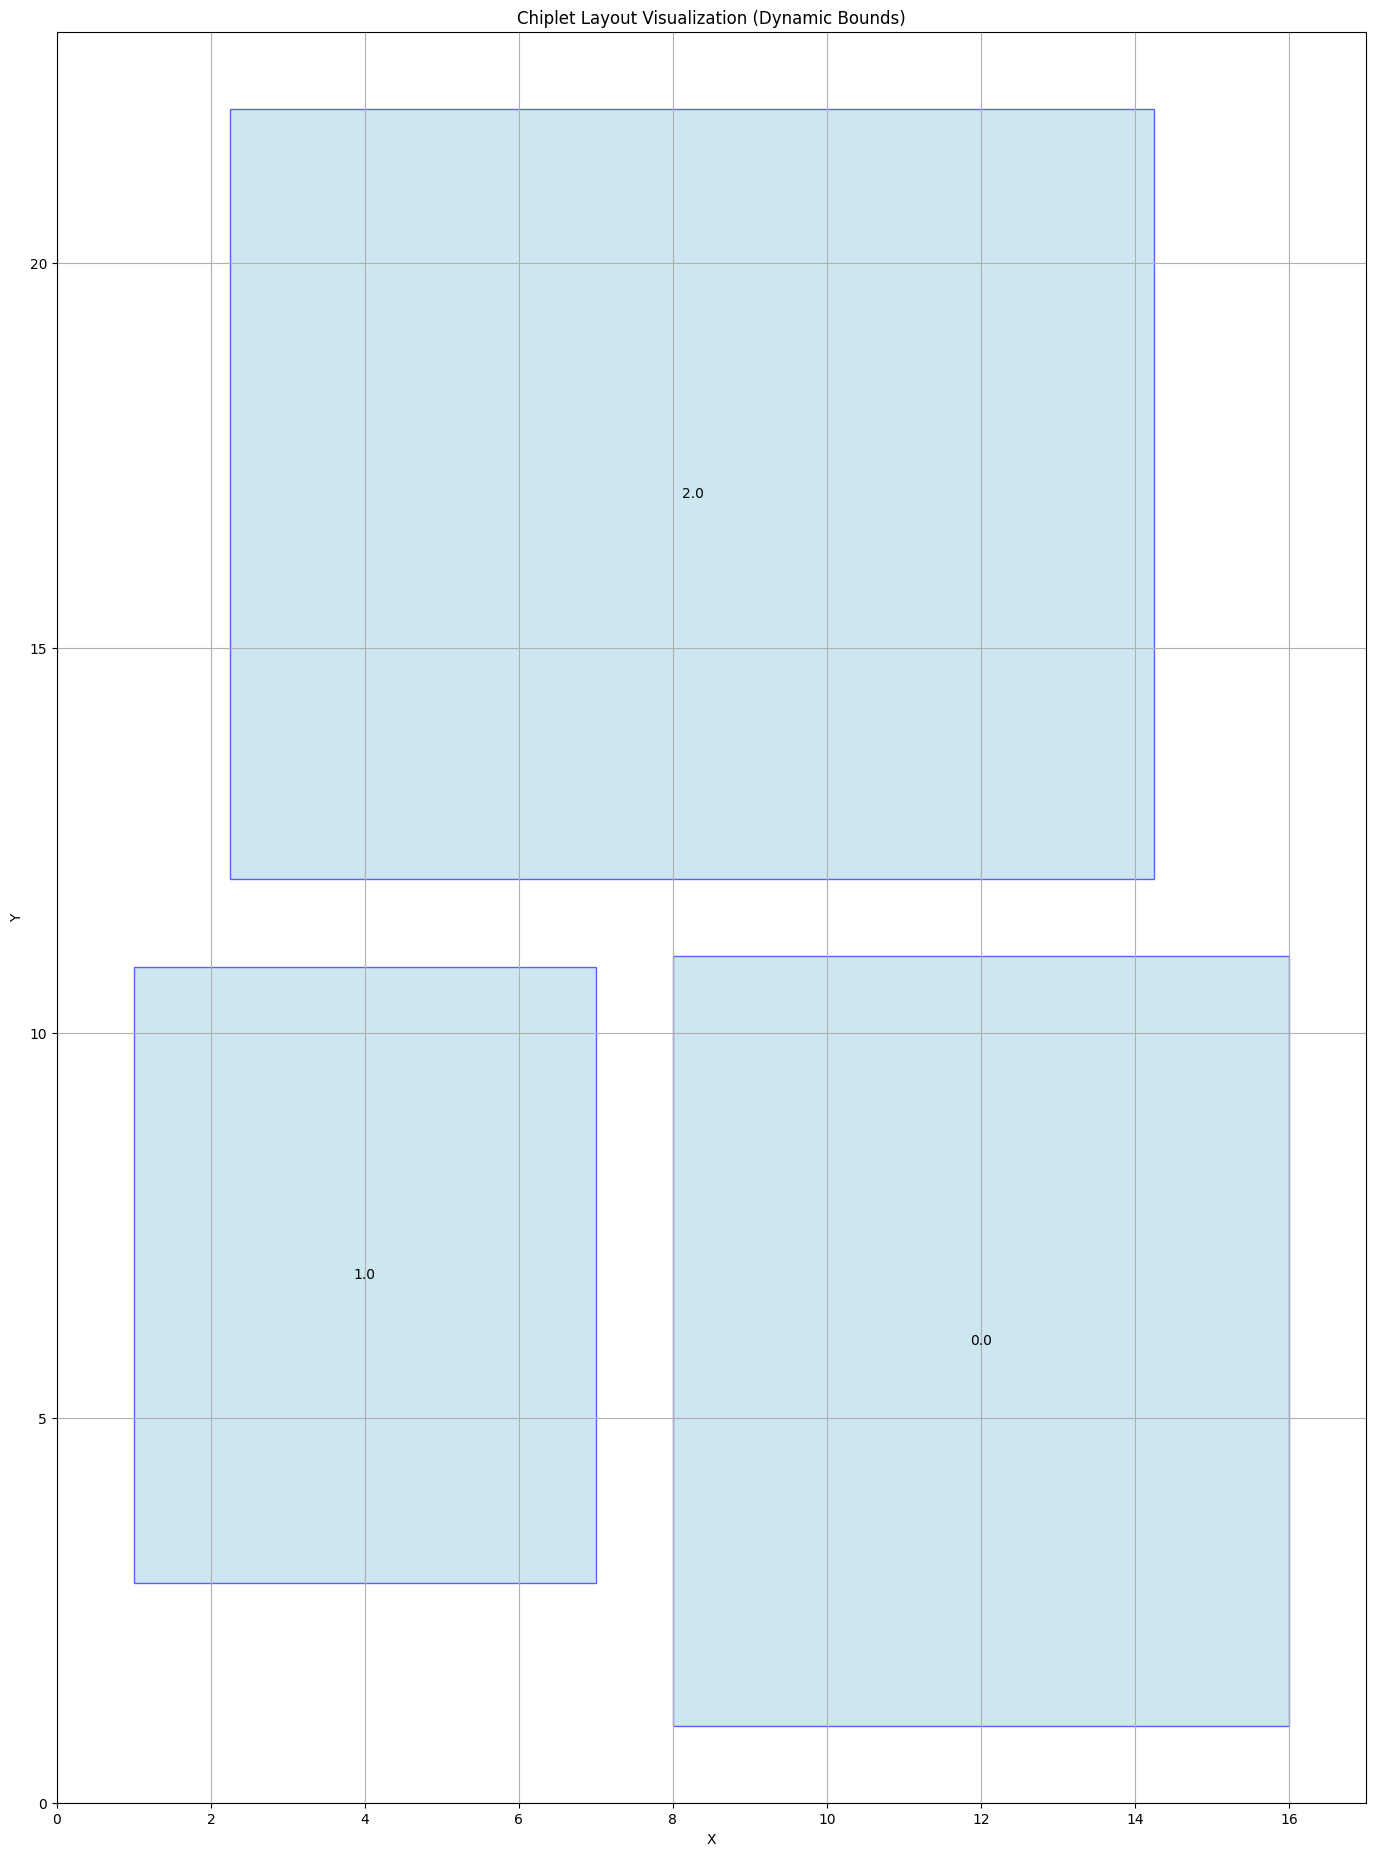

In [13]:
utilities.show_chip_design_cuda(design[0])

In [14]:
import time

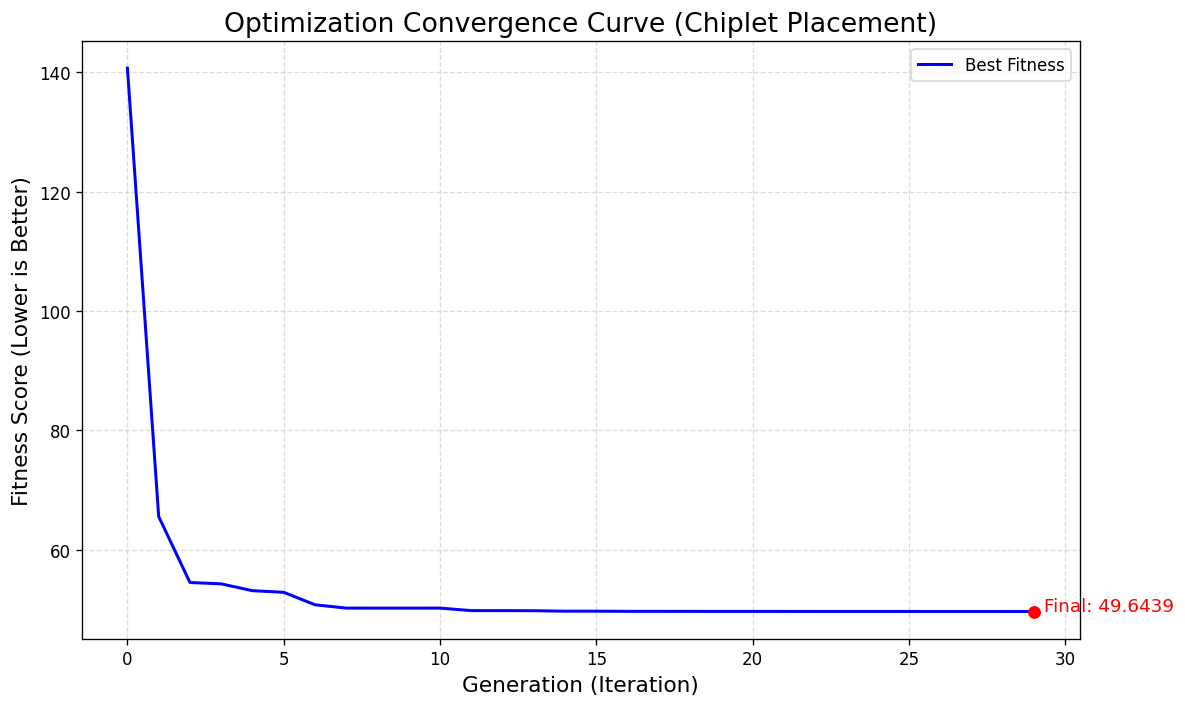

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6), dpi=120)
plt.plot(best_fitness_history, color='blue', linewidth=1.8, label='Best Fitness')

if len(best_fitness_history) > 0:
    x_last = len(best_fitness_history) - 1
    y_last = best_fitness_history[-1]
    plt.scatter([x_last], [y_last], color='red', s=45, zorder=3)
    plt.text(x_last + 0.3, y_last, f'Final: {y_last:.4f}', color='red', fontsize=11)

plt.title('Optimization Convergence Curve (Chiplet Placement)', fontsize=16)
plt.xlabel('Generation (Iteration)', fontsize=13)
plt.ylabel('Fitness Score (Lower is Better)', fontsize=13)
plt.grid(True, linestyle='--', alpha=0.45)
plt.legend(loc='best')
plt.tight_layout()
plt.show()
